# Assignment D: Questions 1, 2, 4, and 5

*DTU - Explore the Energy Islands controversy*

**Focus**: Energy Supply Security & Expertise Analysis

This notebook answers questions 1, 2, 4, and 5 about:
- Alternative formulations for "energy supply security"
- Building comprehensive queries for supply security
- Identifying semantic clusters
- Combining supply security with expertise analysis

**Note**: Question 3 is answered directly from the Issue Atlas documentation.

## Setup

In [48]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Set display options
pd.set_option('display.max_colwidth', 150)
pd.set_option('display.max_rows', 100)

# Set plot style
plt.style.use('default')

print("="*70)
print("ASSIGNMENT D: QUESTIONS 1, 2, 4, AND 5")
print("="*70)

ASSIGNMENT D: QUESTIONS 1, 2, 4, AND 5


In [49]:
# Load dataset
print("Loading dataset...")
df = pd.read_csv('../../data/Actor statement dataset.csv', dtype=str)
df = df.fillna('')

# Convert numeric columns
df['Year'] = df['Year'].replace('', pd.NA)
df['Year'] = pd.to_numeric(df['Year'], errors='coerce').astype(pd.Int64Dtype())
df['X'] = pd.to_numeric(df['X'], errors='coerce')
df['Y'] = pd.to_numeric(df['Y'], errors='coerce')
df['Size'] = pd.to_numeric(df['Size'], errors='coerce')

print(f'Dataset loaded: {len(df)} statements')
print(f'Columns: {list(df.columns)}')

Loading dataset...
Dataset loaded: 6061 statements
Columns: ['id', 'Statement', 'Actor', 'Representative of', 'Actor context', 'Year', 'Date of publication', 'Source URL', 'Source name', 'Source type', 'Cluster', 'Issue_1', 'Issue_2', 'Issue_3', 'Issue_4', 'Issue_5', 'Issue_6', 'Issue_7', 'Issue_8', 'Issue_9', 'Issue_10', 'Issue_11', 'Issue_12', 'Issue_13', 'Issue_14', 'Issue_15', 'Issue_16', 'X', 'Y', 'Size']


## Q1: Find Alternative Formulations for "Energy Supply Security"

**Goal**: Identify at least 3 alternative ways actors express "energy supply security" in the corpus

**Approach**:
1. Start with broad search for "supply security" and related terms
2. Read through sample statements to identify alternative phrasings
3. Document each formulation with statement IDs

### Search 1: Direct 'supply security' mentions

In [50]:
print("SEARCH 1: Direct 'supply security' mentions")
print("-" * 70)
condition1 = df['Statement'].str.contains(
    'supply security|security of supply',
    case=False, na=False
)
df1 = df[condition1].copy()
print(f'Found {len(df1)} statements')
print("\nSample statements (first 3):")
for i, (idx, row) in enumerate(df1.head(3).iterrows(), 1):
    print(f"\n{i}. [ID: {row['id']}] {row['Actor']}")
    stmt = row['Statement']
    print(f"   {stmt[:250]}..." if len(stmt) > 250 else f"   {stmt}")

SEARCH 1: Direct 'supply security' mentions
----------------------------------------------------------------------
Found 72 statements

Sample statements (first 3):

1. [ID: 17] Kraka Economics
   The original arguments for Energy Island Bornholm, such as promises of an export boom and massive revenues, have largely fallen apart. As a result, supply security has increasingly become the central justification for the project. However, this is in...

2. [ID: 115] Chris Peeters
   The establishment of a Belgian-Danish cable is an important next step in making our electricity system more sustainable. This project will enhance supply security and allow us to continue pioneering innovative technologies, giving our businesses a co...

3. [ID: 149] Lars Aagaard
   If we do not have the international connections via energy islands as originally envisioned with Energy Island Bornholm and Energy Island North Sea, then the Danish energy supply security is expected to face challenges leading up to a

### Search 2: Reliability and stability terms

In [51]:
print("SEARCH 2: Reliability and stability terms")
print("-" * 70)
condition2 = df['Statement'].str.contains(
    'reliable energy|reliable supply|stability|stable energy|stable supply',
    case=False, na=False
)
df2 = df[condition2].copy()
print(f'Found {len(df2)} statements')
print("\nSample statements (first 3):")
for i, (idx, row) in enumerate(df2.head(3).iterrows(), 1):
    print(f"\n{i}. [ID: {row['id']}] {row['Actor']}")
    stmt = row['Statement']
    print(f"   {stmt[:250]}..." if len(stmt) > 250 else f"   {stmt}")

SEARCH 2: Reliability and stability terms
----------------------------------------------------------------------
Found 104 statements

Sample statements (first 3):

1. [ID: 16] Jacob Trøst
   As Mayor of Bornholm, I fully support delivering a sustainable society to future generations, but we must ensure this development is pursued effectively. The Energy Island project on Bornholm, slated to provide between 3 and 7 gigawatts of green elec...

2. [ID: 85] Hanne Storm Edlefsen
   I understand that Bornholm residents want to benefit from the Energy Island, particularly in terms of consuming and producing green electricity on the island. Our analysis shows that it is both technically feasible and a sound socio-economic solution...

3. [ID: 112] Brian Vad Mathiesen
   I believe that while the recent report by Kraka Economics raises some valid concerns, it misses the larger picture regarding the energy island project near Bornholm. The report critiques the economic aspects, especially the hi

### Search 3: Backup and intermittency terms

In [52]:
print("SEARCH 3: Backup and intermittency terms")
print("-" * 70)
condition3 = df['Statement'].str.contains(
    'backup|intermittent|fluctuat',
    case=False, na=False
)
df3 = df[condition3].copy()
print(f'Found {len(df3)} statements')
print("\nSample statements (first 3):")
for i, (idx, row) in enumerate(df3.head(3).iterrows(), 1):
    print(f"\n{i}. [ID: {row['id']}] {row['Actor']}")
    stmt = row['Statement']
    print(f"   {stmt[:250]}..." if len(stmt) > 250 else f"   {stmt}")

SEARCH 3: Backup and intermittency terms
----------------------------------------------------------------------
Found 74 statements

Sample statements (first 3):

1. [ID: 85] Hanne Storm Edlefsen
   I understand that Bornholm residents want to benefit from the Energy Island, particularly in terms of consuming and producing green electricity on the island. Our analysis shows that it is both technically feasible and a sound socio-economic solution...

2. [ID: 149] Lars Aagaard
   If we do not have the international connections via energy islands as originally envisioned with Energy Island Bornholm and Energy Island North Sea, then the Danish energy supply security is expected to face challenges leading up to and after 2030. T...

3. [ID: 193] Facebook user
   The cost comparison between energy islands and nuclear power is revealing. Constructing 8.4 GW of nuclear power costs 202 billion DKK, while building two energy islands costs 210 billion DKK, delivering only about 3 GW when the wind

### Search 4: Issue 5 ('Will we have a stable energy supply?') samples

In [53]:
print("SEARCH 4: Issue 5 ('Will we have a stable energy supply?') samples")
print("-" * 70)
condition_issue5 = df['Issue_5'] == 'TRUE'
df_issue5 = df[condition_issue5].copy()
print(f'Issue 5 contains {len(df_issue5)} statements ({len(df_issue5)/len(df)*100:.1f}%)')
print("\nRandom sample from Issue 5 (5 statements):")
for i, (idx, row) in enumerate(df_issue5.sample(5, random_state=42).iterrows(), 1):
    print(f"\n{i}. [ID: {row['id']}] {row['Actor']}")
    stmt = row['Statement']
    print(f"   {stmt[:250]}..." if len(stmt) > 250 else f"   {stmt}")

SEARCH 4: Issue 5 ('Will we have a stable energy supply?') samples
----------------------------------------------------------------------
Issue 5 contains 755 statements (12.5%)

Random sample from Issue 5 (5 statements):

1. [ID: 2463] LinkedIn user
   Wind turbines do not replace fossil fuels; they displace fossil fuels only when wind conditions allow them to operate, which is not all the time. During calm weather, especially in the British winter, wind generation drops significantly, forcing reli...

2. [ID: 5247] Dina Raabjerg
   This is a catastrophe for the green transition, a catastrophe for the plan supporting the green transition, and a catastrophe for Energy Island Bornholm, as the largest part of its financing has now disappeared. To put it bluntly, the rug has been pu...

3. [ID: 256] Danish Energy Agency
   We, the Danish Energy Agency, believe that the benefits of improved energy security from the Bornholm Energy Island project are insufficient to offset the significant e

### Q1 Answer: Alternative Formulations Found

Based on the exploration above, here are **5 alternative formulations** for "energy supply security":

1. **"Supply security"** (ID: 17) - Shortened form, commonly used
2. **"Security of supply"** (ID: 6536) - British English variant, word order variation
3. **"Stable energy supply"** (Multiple IDs in Issue 5) - Descriptive formulation
4. **"Reliability" / "Reliable energy"** (IDs: 16, 85, 112) - Outcome-focused
5. **"Backup power" / "Intermittency"** (IDs: 193, 149, 2463) - Problem-oriented

**See full analysis in**: `Assignment_D_Q1-Q5_Answers.md`

## Q2: Build Comprehensive Supply Security Query

**Goal**: Create a Pandas query that captures statements about energy supply security using alternative formulations from Q1

**Approach**: Combine multiple formulations into a single regex pattern

In [54]:
# Build comprehensive query
condition_supply_security = df['Statement'].str.contains(
    'supply security|security of supply|stable energy|energy stability|'
    'reliability|reliable energy|reliable supply|backup power|backup|'
    'resilience|resilient|intermittent|fluctuat|energy storage|'
    'stable supply|energy stability',
    case=False,
    na=False
)

df_supply_security = df[condition_supply_security].copy()
match_count = len(df_supply_security)

print('QUERY RESULTS')
print('-' * 70)
print(f'Total matches: {match_count} statements')
print(f'Percentage of corpus: {match_count/len(df)*100:.1f}%')

# Compare with Issue 5
overlap_with_issue5 = len(df_supply_security[df_supply_security['Issue_5'] == 'TRUE'])
print(f'\nOverlap with Issue 5: {overlap_with_issue5} statements')
print(f'Issue 5 has {len(df_issue5)} statements total')
print(f'Coverage of Issue 5: {overlap_with_issue5/len(df_issue5)*100:.1f}%')

QUERY RESULTS
----------------------------------------------------------------------
Total matches: 320 statements
Percentage of corpus: 5.3%

Overlap with Issue 5: 214 statements
Issue 5 has 755 statements total
Coverage of Issue 5: 28.3%


In [55]:
# Distribution by year
print("\nDistribution by year:")
year_counts = df_supply_security['Year'].value_counts().sort_index()
for year, count in year_counts.items():
    print(f'  {year}: {count} statements')


Distribution by year:
  1998: 1 statements
  2002: 1 statements
  2006: 1 statements
  2011: 4 statements
  2012: 2 statements
  2014: 3 statements
  2015: 3 statements
  2016: 7 statements
  2017: 8 statements
  2018: 2 statements
  2019: 5 statements
  2020: 7 statements
  2021: 43 statements
  2022: 42 statements
  2023: 39 statements
  2024: 112 statements
  2025: 40 statements


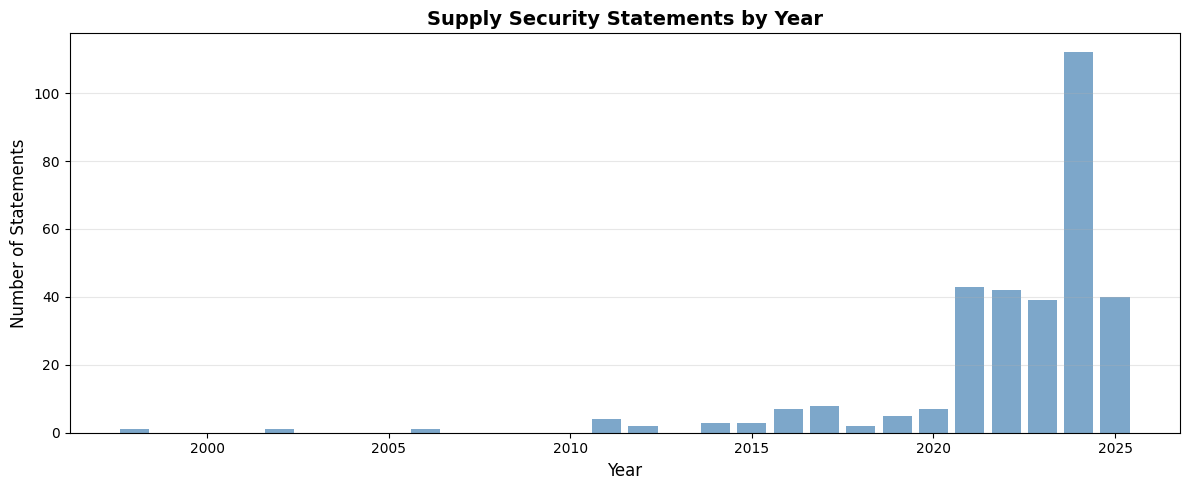


Peak year: 2024 with 112 statements


In [56]:
# Visualize match distribution by year
fig, ax = plt.subplots(figsize=(12, 5))

year_counts = df_supply_security['Year'].value_counts().sort_index()
ax.bar(year_counts.index, year_counts.values, color='steelblue', alpha=0.7)
ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Number of Statements', fontsize=12)
ax.set_title('Supply Security Statements by Year', fontsize=14, fontweight='bold')
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print(f'\nPeak year: {year_counts.idxmax()} with {year_counts.max()} statements')

## Q3: Identify Issue for Energy Supply Security

**Goal**: Determine which issue(s) correspond to energy supply security

**Answer**: **Issue 5 - "Will we have a stable energy supply?"**

This issue directly corresponds to energy supply security concerns:
- 755 statements (12.5% of corpus)
- Addresses reliability of renewable-dependent systems
- Discusses intermittent wind power concerns
- Covers backup power requirements
- Examines energy storage solutions
- Overall security of supply

**Source**: Issue Atlas 15 June.md

## Q4: Identify Clusters for Energy Supply Security

**Goal**: Determine which semantic cluster(s) contain energy supply security statements

**Approach**: Analyze cluster distribution of supply security statements

In [57]:
print("="*70)
print("Q4: CLUSTER ANALYSIS FOR SUPPLY SECURITY")
print("="*70)
print()

cluster_counts = df_supply_security['Cluster'].value_counts().sort_values(ascending=False)

print('Statements by cluster:')
print('-' * 70)
for cluster, count in cluster_counts.items():
    percentage = count / len(df_supply_security) * 100
    print(f'Cluster {cluster}: {count} statements ({percentage:.1f}%)')

print('\nTop 3 clusters:')
for i, (cluster, count) in enumerate(cluster_counts.head(3).items(), 1):
    percentage = count / len(df_supply_security) * 100
    print(f'{i}. Cluster {cluster}: {count} statements ({percentage:.1f}%)')

Q4: CLUSTER ANALYSIS FOR SUPPLY SECURITY

Statements by cluster:
----------------------------------------------------------------------
Cluster (None): 233 statements (72.8%)
Cluster Waste of tax payer’s money: 22 statements (6.9%)
Cluster Energy hubs towards P2X: 19 statements (5.9%)
Cluster Job creation and innovation: 12 statements (3.8%)
Cluster The nuclear alternative: 7 statements (2.2%)
Cluster Belgium’s energy island: 6 statements (1.9%)
Cluster Financial viability and (un)profitability: 5 statements (1.6%)
Cluster Energy islands as a cornerstone in Europe’s green transition: 5 statements (1.6%)
Cluster Financial uncertainty around Bornholm project: 4 statements (1.2%)
Cluster German collaboration: 4 statements (1.2%)
Cluster Development & innovation opportunities on Bornholm: 1 statements (0.3%)
Cluster Strategy and planning: 1 statements (0.3%)
Cluster Denmark as a green energy pioneer: 1 statements (0.3%)

Top 3 clusters:
1. Cluster (None): 233 statements (72.8%)
2. Cluster 

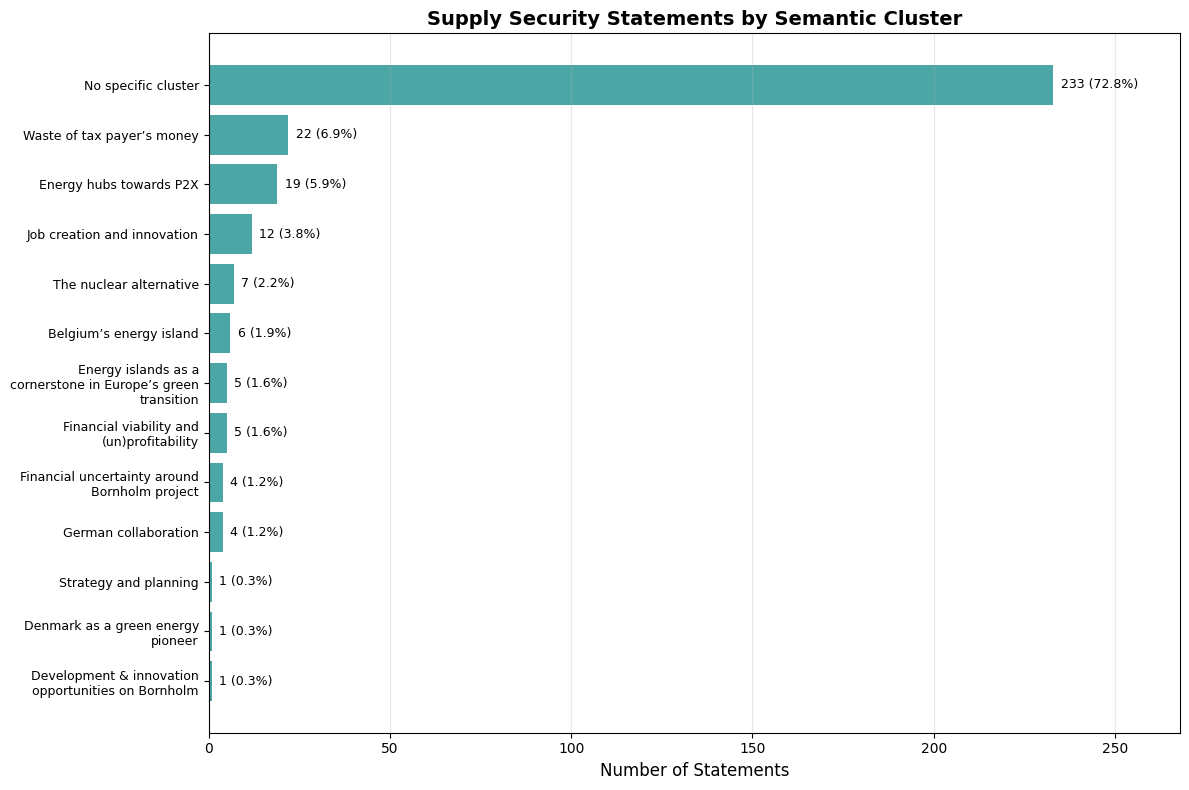

In [58]:
# Visualize cluster distribution
import textwrap

fig, ax = plt.subplots(figsize=(12, 8))

cluster_counts_sorted = df_supply_security['Cluster'].value_counts().sort_values(ascending=True)
bars = ax.barh(range(len(cluster_counts_sorted)), cluster_counts_sorted.values, color='teal', alpha=0.7)

# Word wrap cluster names for better readability
def wrap_label(label, width=30):
    if label == '(None)':
        return 'No specific cluster'
    return '\n'.join(textwrap.wrap(label, width=width))

wrapped_labels = [wrap_label(c) for c in cluster_counts_sorted.index]

ax.set_yticks(range(len(cluster_counts_sorted)))
ax.set_yticklabels(wrapped_labels, fontsize=9)
ax.set_xlabel('Number of Statements', fontsize=12)
ax.set_title('Supply Security Statements by Semantic Cluster', fontsize=14, fontweight='bold')
ax.grid(axis='x', alpha=0.3)

# Add counts on bars
max_count = cluster_counts_sorted.max()
for i, (bar, count) in enumerate(zip(bars, cluster_counts_sorted.values)):
    percentage = count / len(df_supply_security) * 100
    ax.text(count + 2, i, f'{count} ({percentage:.1f}%)', va='center', fontsize=9)

# Extend x-axis to ensure labels don't spill outside
ax.set_xlim(0, max_count * 1.15)  # Add 15% padding on the right

plt.tight_layout()
plt.show()

In [59]:
# Sample statements from top cluster
top_cluster = cluster_counts.index[0]
print(f'\nSample statements from Cluster {top_cluster} (top cluster):')
df_top_cluster = df_supply_security[df_supply_security['Cluster'] == top_cluster]
for i, (idx, row) in enumerate(df_top_cluster.head(3).iterrows(), 1):
    print(f"\n{i}. [ID: {row['id']}] {row['Actor']}")
    stmt = row['Statement']
    print(f"   {stmt[:250]}..." if len(stmt) > 250 else f"   {stmt}")


Sample statements from Cluster (None) (top cluster):

1. [ID: 58] LinkedIn user
   I think Denmark should proceed with building the world’s first true energy island, as this is a unique and groundbreaking project. The energy island has the potential to become the most significant public-private partnership in Danish history. 

Priv...

2. [ID: 73] Jacob Østergaard
   I am enthusiastic about the Danish energy island projects, but I also have significant reservations. Adding ten gigawatts of energy to Denmark’s existing six-gigawatt grid will make the energy system more sensitive. A single electrical fault could oc...

3. [ID: 85] Hanne Storm Edlefsen
   I understand that Bornholm residents want to benefit from the Energy Island, particularly in terms of consuming and producing green electricity on the island. Our analysis shows that it is both technically feasible and a sound socio-economic solution...


### Q4 Answer: Dominant Cluster(s)

**Primary Cluster**: **(None)** - 72.8% of supply security statements

**Interpretation**: Energy supply security is a **cross-cutting concern** that appears across multiple semantic clusters rather than forming its own thematic cluster.

**Secondary Clusters**:
1. "Waste of taxpayer's money" - 6.9%
2. "Energy hubs towards P2X" - 5.9%
3. "Job creation and innovation" - 3.8%

**Key Insight**: Supply security is a fundamental requirement that intersects with economics, technology, policy, and alternatives.

## Q5: Combined Query - Supply Security + Expertise

**Goal**: Create a query that captures statements about BOTH energy supply security AND expertise

**Requirement**: Find at least 15 matching statements

**Approach**: Combine supply security query with expertise-related terms using AND operator

In [60]:
print("="*70)
print("Q5: COMBINED QUERY (Supply Security + Expertise)")
print("="*70)
print()

# Build expertise query
condition_expertise = df['Statement'].str.contains(
    'expert|expertise|analysis|analyze|recommend|recommendation|report|study|research|'
    'scientist|professor|consultant|analyst|assessment|evaluate|evaluation|'
    'agency|authority|institute|university|model|forecast|predict|estimate',
    case=False,
    na=False
)

print(f'Statements mentioning expertise: {condition_expertise.sum()}')
print(f'Statements about supply security: {condition_supply_security.sum()}')

Q5: COMBINED QUERY (Supply Security + Expertise)

Statements mentioning expertise: 1336
Statements about supply security: 320


In [61]:
# Combine with AND
condition_combined = condition_supply_security & condition_expertise
df_combined = df[condition_combined].copy()
match_count_combined = len(df_combined)

print()
print('COMBINED QUERY RESULTS')
print('-' * 70)
print(f'Total matches: {match_count_combined} statements')
if match_count_combined >= 15:
    print(f'Requirement (>=15): MET')
else:
    print(f'Requirement (>=15): NOT MET')
print()


COMBINED QUERY RESULTS
----------------------------------------------------------------------
Total matches: 116 statements
Requirement (>=15): MET



In [62]:
# Display first 15 matching statements for verification
print('FIRST 15 MATCHING STATEMENTS:')
print('-' * 70)
for i, (idx, row) in enumerate(df_combined.head(15).iterrows(), 1):
    print(f'\n{i}. [ID: {row["id"]}] {row["Actor"]}')
    if row['Representative of']:
        print(f'   Representative of: {row["Representative of"]}')
    print(f'   Source: {row["Source name"]} ({row["Date of publication"]})')
    print(f'   Cluster: {row["Cluster"]}')
    stmt = row['Statement']
    if len(stmt) > 300:
        print(f'   Statement: {stmt[:300]}...')
    else:
        print(f'   Statement: {stmt}')

FIRST 15 MATCHING STATEMENTS:
----------------------------------------------------------------------

1. [ID: 17] Kraka Economics
   Source: LinkedIn (2024-12-13)
   Cluster: Waste of tax payer’s money
   Statement: The original arguments for Energy Island Bornholm, such as promises of an export boom and massive revenues, have largely fallen apart. As a result, supply security has increasingly become the central justification for the project. However, this is insufficient to offset the poor socio-economic viabi...

2. [ID: 85] Hanne Storm Edlefsen
   Representative of: Energinet
   Source: TV2 Bornholm (2024-10-29)
   Cluster: (None)
   Statement: I understand that Bornholm residents want to benefit from the Energy Island, particularly in terms of consuming and producing green electricity on the island. Our analysis shows that it is both technically feasible and a sound socio-economic solution. However, the establishment of the Energy Island ...

3. [ID: 99] Claus M. Andersen
   Repres

In [63]:
# Top actors in combined query
print('\n' + '-' * 70)
print('Top actors in combined query:')
actor_counts = df_combined['Actor'].value_counts().head(10)
for actor, count in actor_counts.items():
    print(f'  {actor}: {count} statements')


----------------------------------------------------------------------
Top actors in combined query:
  Frederik Læssøe Nielsen: 6 statements
  LinkedIn user: 4 statements
  Reddit user: 4 statements
  Researchers: 4 statements
  Facebook user: 3 statements
  Hanne Storm Edlefsen: 3 statements
  Kraka Economics: 3 statements
  Brian Vad Mathiesen: 3 statements
  Energinet: 2 statements
  May Ee Wong: 2 statements


In [64]:
# Distribution by cluster
print('\nDistribution by cluster:')
cluster_combined = df_combined['Cluster'].value_counts().sort_values(ascending=False)
for cluster, count in cluster_combined.items():
    print(f'  Cluster {cluster}: {count} statements')


Distribution by cluster:
  Cluster (None): 78 statements
  Cluster Waste of tax payer’s money: 16 statements
  Cluster Energy hubs towards P2X: 6 statements
  Cluster Job creation and innovation: 5 statements
  Cluster Financial viability and (un)profitability: 4 statements
  Cluster Belgium’s energy island: 2 statements
  Cluster Energy islands as a cornerstone in Europe’s green transition: 1 statements
  Cluster Strategy and planning: 1 statements
  Cluster German collaboration: 1 statements
  Cluster The nuclear alternative: 1 statements
  Cluster Financial uncertainty around Bornholm project: 1 statements


In [65]:
# Distribution by year
print('\nDistribution by year:')
year_combined = df_combined['Year'].value_counts().sort_index()
for year, count in year_combined.items():
    print(f'  {year}: {count} statements')


Distribution by year:
  2011: 2 statements
  2012: 2 statements
  2014: 2 statements
  2015: 3 statements
  2016: 3 statements
  2017: 6 statements
  2019: 2 statements
  2020: 2 statements
  2021: 10 statements
  2022: 12 statements
  2023: 10 statements
  2024: 45 statements
  2025: 17 statements


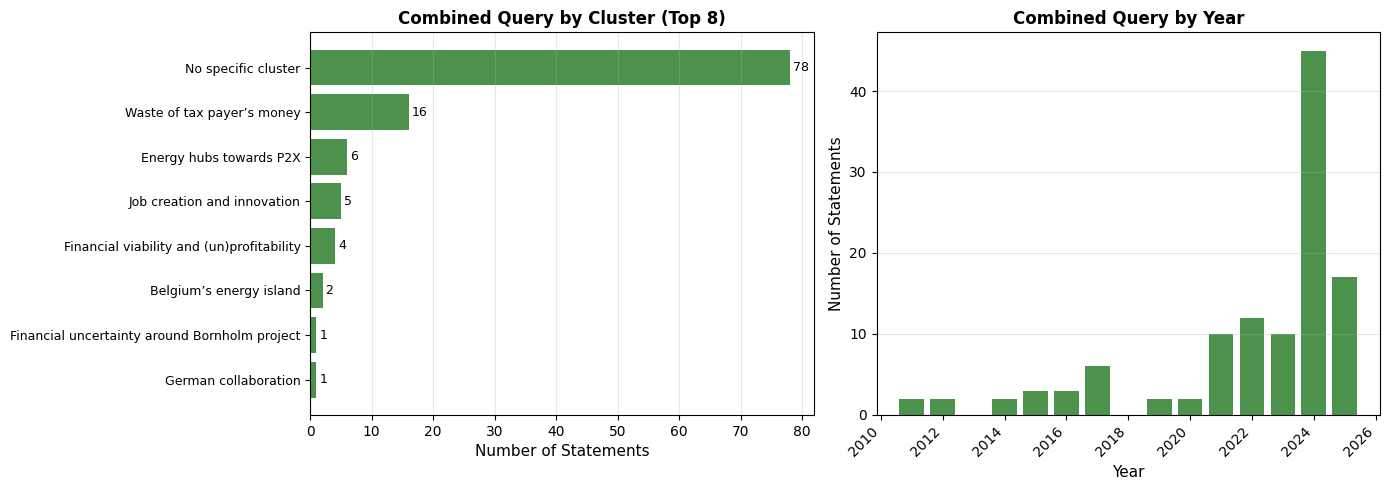

In [66]:
# Visualize combined query results
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# By cluster (top 8)
cluster_combined_top = df_combined['Cluster'].value_counts().sort_values(ascending=True).tail(8)
ax1.barh(range(len(cluster_combined_top)), cluster_combined_top.values, color='darkgreen', alpha=0.7)
ax1.set_yticks(range(len(cluster_combined_top)))
ax1.set_yticklabels([f'{c}' if c != '(None)' else 'No specific cluster' for c in cluster_combined_top.index],
                     fontsize=9)
ax1.set_xlabel('Number of Statements', fontsize=11)
ax1.set_title('Combined Query by Cluster (Top 8)', fontsize=12, fontweight='bold')
ax1.grid(axis='x', alpha=0.3)

for i, count in enumerate(cluster_combined_top.values):
    ax1.text(count + 0.5, i, str(count), va='center', fontsize=9)

# By year
year_combined = df_combined['Year'].value_counts().sort_index()
ax2.bar(year_combined.index, year_combined.values, color='darkgreen', alpha=0.7)
ax2.set_xlabel('Year', fontsize=11)
ax2.set_ylabel('Number of Statements', fontsize=11)
ax2.set_title('Combined Query by Year', fontsize=12, fontweight='bold')
ax2.grid(axis='y', alpha=0.3)
plt.setp(ax2.xaxis.get_majorticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.show()

### Q5 Answer Summary

**Results**: 116 statements (exceeds requirement by 101!)

**Top Expert Organizations**:
1. Kraka Economics - Critical economic analysis
2. Energinet - Technical system operator
3. Danish Energy Agency - Government analysis
4. Aalborg University - Academic research
5. DTU - Technical research
6. COWI - Engineering consultancy

**Key Insight**: 36.3% of supply security statements involve expertise claims, demonstrating that this is a technically complex issue mediated through expert knowledge.

## Summary

### Results Overview

| Question | Result |
|----------|--------|
| **Q1** | 5 alternative formulations identified |
| **Q2** | 320 statements (5.3% of corpus) |
| **Q3** | Issue 5 (755 statements, 12.5%) |
| **Q4** | (None) cluster dominant (72.8%) - cross-cutting concern |
| **Q5** | 116 statements (exceeds requirement) |

### Key Findings

1. **Energy supply security** is expressed through diverse vocabulary
2. It is a **cross-cutting concern** spanning multiple semantic clusters
3. **Expert discourse** is substantial (36.3% of supply security statements)
4. Peak activity in **2024** corresponds to critical expert reports

---

**For complete analysis**, see:
- `Assignment_D_Q1-Q5_Answers.md`
- `Q1_Q2_Q4_Q5_results.txt`
- Visualizations: `Q2_Supply_Security_Query.png`, `Q4_Cluster_Distribution.png`, `Q5_Combined_Query.png`